In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("house_price_prediction_dataset.csv")

print(df.head())
print(df.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

##### Target Variable

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

##### missing values

In [21]:
## missing values4

missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing.sort_values(ascending=False))


Series([], dtype: int64)


##### Split Numerical & Categorical Features

In [22]:
###Handle Missing Values (Simple Way)
# Numerical columns → fill with median
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 39
Categorical: 0


#### Target distribution

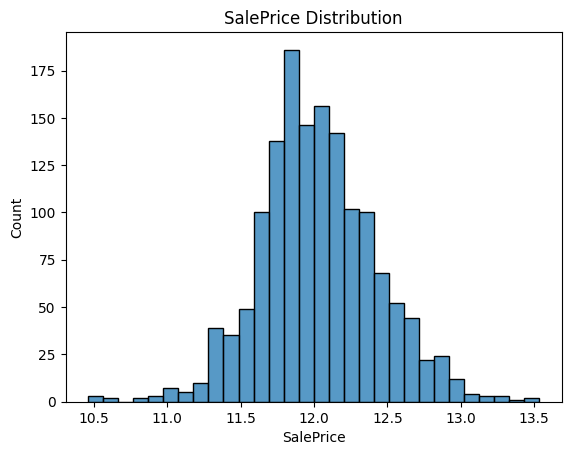

In [23]:
sns.histplot(df['SalePrice'], bins=30)
plt.title("SalePrice Distribution")
plt.show()

##### Log Transformation

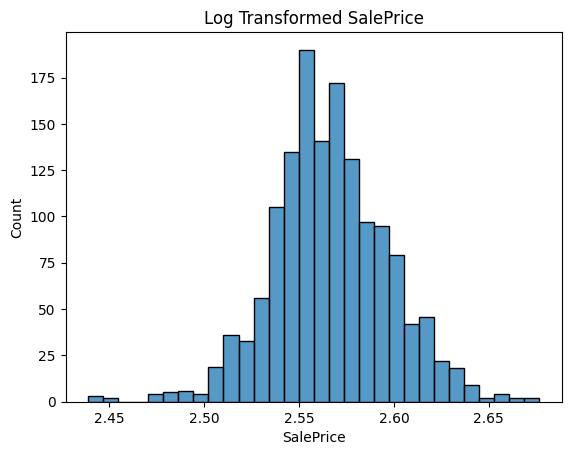

In [24]:
df['SalePrice'] = np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice'], bins=30)
plt.title("Log Transformed SalePrice")
plt.show()

### Correlatin Heatmap

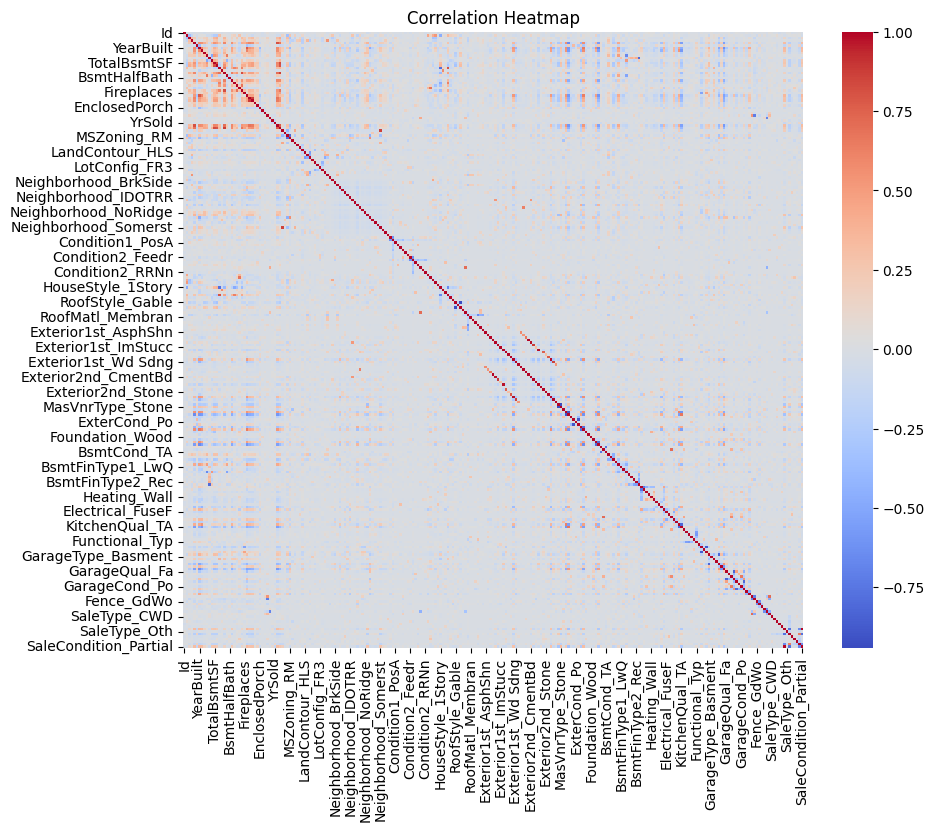

In [26]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Top Correlated Features

In [28]:
top_corr = corr['SalePrice'].sort_values(ascending=False)
print(top_corr.head(10))

SalePrice      1.000000
OverallQual    0.815005
TotalSF        0.773216
GrLivArea      0.697001
GarageCars     0.680156
GarageArea     0.649601
TotalBsmtSF    0.609138
FullBath       0.593950
1stFlrSF       0.593533
YearBuilt      0.587947
Name: SalePrice, dtype: float64


### Bi-variant analysis

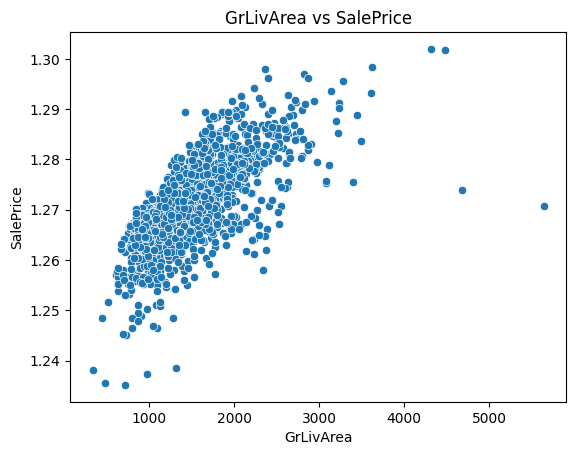

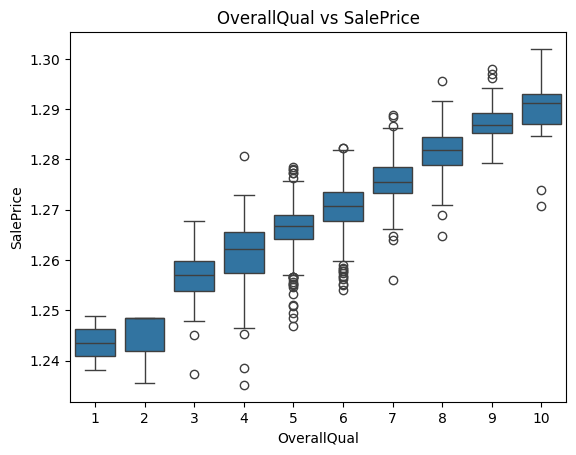

In [29]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("GrLivArea vs SalePrice")
plt.show()

sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title("OverallQual vs SalePrice")
plt.show()

#### Handle Missing Values

In [30]:
# numerical
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### Feature engineering

In [37]:
# total area
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#### Encoding

In [38]:
df = pd.get_dummies(df, drop_first=True)

House prices depend strongly on:

overall quality (OverallQual)

living area (GrLivArea)

garage size

Log transformation improved model performance

Random Forest performed better than Linear Regression

Feature engineering (TotalSF) improved accuracy

This project used EDA, preprocessing, and regression models to predict house prices. After handling missing values and encoding categorical features, Random Forest gave the best performance. Important factors influencing house prices include overall quality, living area, and total square footage.

####train and spllit

In [45]:
from sklearn.model_selection import train_test_split

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### linear regression

In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

#### Ridge regression

In [47]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

##### Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

##### Evaluation

In [49]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Linear RMSE:", rmse(y_test, y_pred_lr))
print("Ridge RMSE:", rmse(y_test, y_pred_ridge))
print("RF RMSE:", rmse(y_test, y_pred_rf))

Linear RMSE: 0.004557158968280412
Ridge RMSE: 0.0030386106029257364
RF RMSE: 0.0033154031520031776


#### Feature importane

In [50]:
importance = rf.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df.head(10))

          Feature  Importance
4     OverallQual    0.391767
37        TotalSF    0.359636
26     GarageCars    0.018433
190  CentralAir_Y    0.016870
6       YearBuilt    0.015725
16      GrLivArea    0.013818
27     GarageArea    0.012897
3         LotArea    0.011802
7    YearRemodAdd    0.011233
9      BsmtFinSF1    0.009483
